In [105]:
import numpy as np
import pandas as pd
import keras
#!pip install opencv-python
import cv2
from matplotlib import pyplot as plt
import os
import random
from PIL import Image
import tarfile

In [132]:
#samples=20000
df=pd.read_csv("train.csv")
base_path=r"./images/"

In [107]:
df

,id,url,landmark_id
0,6e158a47eb2ca3f6,https://upload.wikimedia.org/wikipedia/commons...,142820
1,202cd79556f30760,http://upload.wikimedia.org/wikipedia/commons/...,104169
2,3ad87684c99c06e1,http://upload.wikimedia.org/wikipedia/commons/...,37914
3,e7f70e9c61e66af3,https://upload.wikimedia.org/wikipedia/commons...,102140
4,4072182eddd0100e,https://upload.wikimedia.org/wikipedia/commons...,2474
...,...,...,...
4132909,fc0f007893b11ba7,https://upload.wikimedia.org/wikipedia/commons...,172138
4132910,39aad18585867916,https://upload.wikimedia.org/wikipedia/commons...,162860
4132911,fd0725460e4ebbec,https://upload.wikimedia.org/wikipedia/commons...,191243
4132912,73691ae29e24ba19,https://upload.wikimedia.org/wikipedia/commons...,145760


In [108]:
samples=20000
df=df.loc[df["id"].str.startswith('00', na=False), :]
num_classes=len(df["landmark_id"].unique())
num_data=len(df)

In [109]:
num_classes

13589

In [110]:
num_data

16157

In [111]:
data= pd.DataFrame (df["landmark_id"].value_counts())
data.reset_index(inplace=True)
data.head() 

,landmark_id,count
0,138982,47
1,62798,18
2,83144,14
3,171772,13
4,176528,12


In [112]:
data.tail()

,landmark_id,count
13584,54986,1
13585,182355,1
13586,25204,1
13587,100559,1
13588,63972,1


In [114]:
data.colunms=['count', 'landmark_id']

In [115]:
data['count'].describe()

count    13589.000000
mean         1.188976
std          0.727458
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         47.000000
Name: count, dtype: float64

In [116]:
data['landmark_id'].describe()

count     13589.000000
mean     101833.646700
std       58898.626573
min           0.000000
25%       50255.000000
50%      101438.000000
75%      153527.000000
max      203073.000000
Name: landmark_id, dtype: float64

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([ 0.  ,  0.58,  1.16,  1.74,  2.32,  2.9 ,  3.48,  4.06,  4.64,
         5.22,  5.8 ,  6.38,  6.96,  7.54,  8.12,  8.7 ,  9.28,  9.86,
        10.44, 11.02, 11.6 , 12.18, 12.76, 13.34, 13.92, 14.5 , 15.08,
        15.66, 16.24, 16.82, 17.4 , 17.98, 18.56, 19.14, 19.72, 20.3 ,
        20.88, 21.46, 22.04, 22.62, 23.2 , 23.78, 24.36, 24.94, 25.52,
        26.1 , 26.68, 27.26, 27.84, 28.42, 29.  , 29.58, 30.16, 30.74,
        31.32, 31.9 , 32.48, 33.06, 33.64, 34.22, 34.8 , 35.38, 35.96,
        36.54, 37.12, 37.7 , 38.28, 38.86, 39.44, 40.

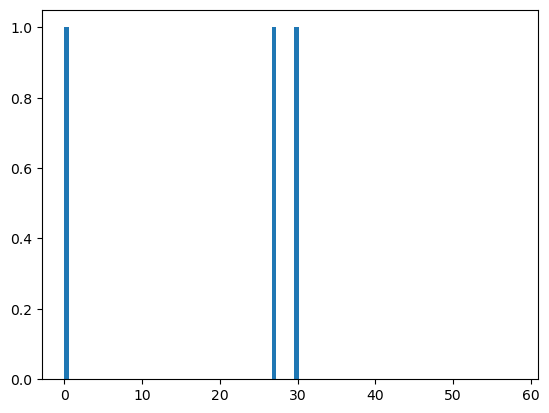

In [117]:
plt.hist(data['landmark_id'], 100, range= (0,58), label= 'test')

In [118]:
data['count'].between(5,10).sum()

69

(array([1., 2., 1., ..., 1., 1., 5.]),
 array([0.00000e+00, 2.70000e+01, 3.00000e+01, ..., 2.03062e+05,
        2.03071e+05, 2.03073e+05]),
 <BarContainer object of 13588 artists>)

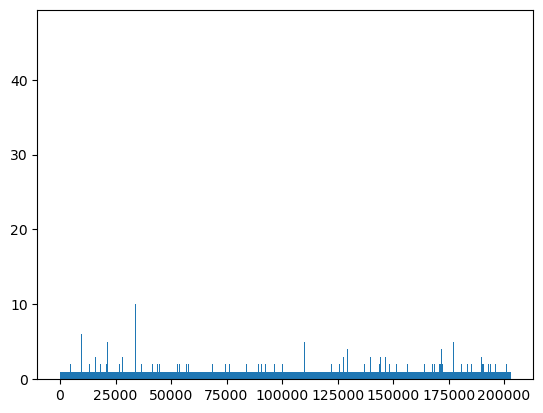

In [119]:
plt.hist(df["landmark_id"], bins = sorted(df["landmark_id"].unique()))

In [120]:
from sklearn.preprocessing import LabelEncoder
lencoder= LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [121]:
df.head()

,id,url,landmark_id
108,0036d78c05c194d9,https://upload.wikimedia.org/wikipedia/commons...,50089
172,00c08b162f34f53f,https://upload.wikimedia.org/wikipedia/commons...,163404
710,00e5d77c905d94a6,https://upload.wikimedia.org/wikipedia/commons...,26066
1256,00c8dba0df4d112a,https://upload.wikimedia.org/wikipedia/commons...,35744
1262,001cd787f1e9a803,https://upload.wikimedia.org/wikipedia/commons...,61937


In [122]:
def encode_label(lbl):
    return lencoder.transform(lbl)

In [123]:
def decode_label(lbl):
    return lencoder.inverse_transform(161)

In [133]:
def get_image_from_number(num):
    fname, label= df.loc[num, :]
    fname = fname+ '.jpg'
    f1 =fname[0]
    f2 =fname [1]
    f3 =fname[2]
    path= os.path.join(f1, f2, f3, fname)
    im =cv2.imread(os.path.join(base_path, path))
    return im, label

In [134]:
print("4 Sample images from random classes")
fig= plt.figure(figsize=(16,16))
for i in range(1,5):
    ri =random.choices(os.listdir(base_path), k=3)
    folder =base_path + '/' + ri[0]+'/'+ri[1]+'/' + ri[2]
    random_img= random.choice (os.listdir(folder))
    img =np.array(Image.open(folder +'/'+random_img))
    fig.add_subplot(1,4,i)
    plt.imshow(img)
    plt.axis('off')
plt.show()

4 Sample images from random classes


FileNotFoundError: [WinError 3] The system cannot find the path specified: './images/'

<Figure size 1600x1600 with 0 Axes>

In [146]:
from keras.applications.vgg19 import VGG19
from keras.layers import *
from keras import Sequential
tf.compat.v1.disable_eager_execution()

In [137]:
#Parameters
learning_rate= 0.0001
decay_speed=10-6
momemtum=0.09
loss_function="sparse_categorical_crossentropy"
source_model= VGG19(weights=None)
drop_layer= Dropout (0.5)
drop_layer2= Dropout(0.5)

In [139]:
model= Sequential()
for layer in source_model.layers[:-1]:
    if layer== source_model.layers[-25]:
        model.add(BatchNormalization())
    model.add(layer)
model.add(Dense(num_classes, activation= "softmax"))
model.summary()

Instructions for updating:
Colocations handled automatically by placer.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (BatchN  (None, 224, 224, 3)      12        
 ormalization)                                                   
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)

In [147]:
optimi= keras.optimizer_v1.RMSprop(lr = learning_rate)
model.compile(optimizer=optimi,
              loss=loss_function,
              metrics=["accuracy"])

AttributeError: module 'keras' has no attribute 'optimizer_v1'

In [148]:
def image_reshape(im, target_size):
    return cv2.reshape(im, target_size)

In [173]:
def get_batch(dataframe, start, batch_size):
    image_array=[]
    label_array=[]
    end_img= start+batch_size
    if(end_img) > len(dataframe):
        end_img= len(dataframe)
    for idx in range(start, end_img):
        n=idx
        im, label = get_image_from_number(n, dataframe)
        im =image_reshape(im, (224, 224)) / 255.0
        image_array.append(im)
        label_array.append(label)
    label_array= encode_label(label_array)
    return np.array(image_array), np.array (label_array)

In [174]:
batch_size = 16
epoch_shuffle = True
weight_classes = True
epochs= 1
# split
train, val = np.split(df.sample(frac=1), [int(0.8*len (df))])
print(len(train))
print(len(val))

3306331
826583


In [175]:
for e in range(epochs):
    print("Epoch: "+ str (e+1) + "/"+ str(epochs))
    if epoch_shuffle:
        train= train.sample(frac=1)
    for it in range(int(np.ceil(len(train)/batch_size))):
        X_train, y_train= get_batch(train, it*batch_size, batch_size)
        
        model.train_on_batch(X_train, y_train)
model.save("Model")

Epoch: 1/1


TypeError: get_image_from_number() takes 1 positional argument but 2 were given

In [176]:
#Test
batch_size= 16
errors= 0
good_preds = []
bad_pred = []
for it in range(int(np.ceil(len(val)/batch_size))):
    X_val, y_val = get_batch(val, it*batch_size, batch_size)
    result =model.predict(X_val)
    cla -np.argmax(result, axis-1)
    for idx, res in enumerate(result):
        if cla[idx]!= y_val [idx]:
            errors= errors + 1
            bad_preds.append([batch_size*it+ idx], cla[idx], res [cla[idx]])
        else:
            good_preds.append([batch_size*it + idx], cla[idx], res[cla[idx]])
for i in range(1,6):
    n=int(good_preds[0])
    img, lbl= get_image_from_number(n, val)
    imgcv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)

TypeError: get_image_from_number() takes 1 positional argument but 2 were given